# Multinomial Naive Bayes - 20newsgroup

In [1]:
import re
import math
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd

In [2]:
dataset_root = Path('/kaggle/input/datasets/wunderbarx/20-newsgroup/20_newsgroups')

if not dataset_root.is_dir():
    raise FileNotFoundError(
        f'Invalid path: {dataset_root}. Update dataset_root in this cell.'
    )

print('Dataset root:', dataset_root)

Dataset root: /kaggle/input/datasets/wunderbarx/20-newsgroup/20_newsgroups


In [3]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\\s]', ' ', text)
    text = re.sub(r'\\s+', ' ', text).strip()
    return text


def tokenize(text):
    text = clean_text(text)
    tokens = text.split()
    return [t for t in tokens if len(t) > 1]


def read_documents_from_class_folders(root_folder):
    docs = []
    labels = []

    class_dirs = sorted([p for p in root_folder.iterdir() if p.is_dir()])

    for class_dir in class_dirs:
        for fpath in sorted(class_dir.iterdir()):
            if not fpath.is_file():
                continue
            try:
                with open(fpath, 'r', encoding='latin1', errors='ignore') as f:
                    text = f.read()
                docs.append(text)
                labels.append(class_dir.name)
            except Exception:
                continue

    return docs, labels


def split_train_test(texts, labels, test_size=0.2, random_state=42):
    rng = np.random.default_rng(seed=random_state)
    indices = np.arange(len(texts))
    rng.shuffle(indices)

    test_count = int(len(texts) * test_size)
    test_idx = indices[:test_count]
    train_idx = indices[test_count:]

    x_train = [texts[i] for i in train_idx]
    y_train = [labels[i] for i in train_idx]
    x_test = [texts[i] for i in test_idx]
    y_test = [labels[i] for i in test_idx]

    return x_train, x_test, y_train, y_test

In [4]:
all_texts, all_labels = read_documents_from_class_folders(dataset_root)
train_texts, test_texts, y_train, y_test = split_train_test(
    all_texts, all_labels, test_size=0.2, random_state=42
)

print('Using random 80/20 split from class folders.')
print('Total docs:', len(all_texts))
print('Train docs:', len(train_texts))
print('Test docs :', len(test_texts))
print('Unique classes:', len(sorted(set(y_train))))

Using random 80/20 split from class folders.
Total docs: 19997
Train docs: 15998
Test docs : 3999
Unique classes: 20


In [5]:
class MultinomialNaiveBayes:
    def __init__(self, alpha=1.0, min_token_freq=2):
        self.alpha = alpha
        self.min_token_freq = min_token_freq

        self.classes_ = []
        self.class_doc_count_ = Counter()
        self.class_log_prior_ = {}

        self.vocab_ = {}
        self.vocab_size_ = 0

        self.class_word_counts_ = {}
        self.class_total_words_ = {}

    def _build_vocab(self, tokenized_texts):
        global_counts = Counter()
        for tokens in tokenized_texts:
            global_counts.update(tokens)

        vocab_tokens = [w for w, c in global_counts.items() if c >= self.min_token_freq]
        vocab_tokens.sort()
        self.vocab_ = {w: i for i, w in enumerate(vocab_tokens)}
        self.vocab_size_ = len(self.vocab_)

    def fit(self, texts, labels):
        labels = list(labels)
        tokenized = [tokenize(t) for t in texts]

        self._build_vocab(tokenized)
        self.classes_ = sorted(set(labels))

        n_docs = len(texts)
        for c in self.classes_:
            self.class_word_counts_[c] = np.zeros(self.vocab_size_, dtype=np.float64)
            self.class_total_words_[c] = 0.0

        for tokens, c in zip(tokenized, labels):
            self.class_doc_count_[c] += 1
            for w in tokens:
                idx = self.vocab_.get(w)
                if idx is not None:
                    self.class_word_counts_[c][idx] += 1.0
                    self.class_total_words_[c] += 1.0

        for c in self.classes_:
            self.class_log_prior_[c] = math.log(self.class_doc_count_[c] / n_docs)

    def _predict_one(self, text):
        tokens = tokenize(text)
        token_counts = Counter(w for w in tokens if w in self.vocab_)

        best_class = None
        best_score = -float('inf')

        for c in self.classes_:
            log_prob = self.class_log_prior_[c]
            denom = self.class_total_words_[c] + self.alpha * self.vocab_size_

            word_count_vec = self.class_word_counts_[c]
            for w, cnt in token_counts.items():
                idx = self.vocab_[w]
                num = word_count_vec[idx] + self.alpha
                log_prob += cnt * math.log(num / denom)

            if log_prob > best_score:
                best_score = log_prob
                best_class = c

        return best_class

    def predict(self, texts):
        return [self._predict_one(t) for t in texts]

In [6]:
def confusion_matrix_manual(y_true, y_pred, class_names):
    class_to_idx = {c: i for i, c in enumerate(class_names)}
    cm = np.zeros((len(class_names), len(class_names)), dtype=int)

    for t, p in zip(y_true, y_pred):
        if (t in class_to_idx) and (p in class_to_idx):
            cm[class_to_idx[t], class_to_idx[p]] += 1

    return cm


def metrics_from_confusion_matrix(cm):
    total = cm.sum()
    correct = np.trace(cm)
    accuracy = correct / total if total > 0 else 0.0

    precisions = []
    recalls = []

    n_classes = cm.shape[0]
    for i in range(n_classes):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp

        p = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        r = tp / (tp + fn) if (tp + fn) > 0 else 0.0

        precisions.append(p)
        recalls.append(r)

    macro_precision = float(np.mean(precisions)) if precisions else 0.0
    macro_recall = float(np.mean(recalls)) if recalls else 0.0

    return accuracy, macro_precision, macro_recall, precisions, recalls

In [7]:
mnb = MultinomialNaiveBayes(alpha=1.0, min_token_freq=2)
mnb.fit(train_texts, y_train)

print('Vocabulary size:', mnb.vocab_size_)
print('Classes       :', len(mnb.classes_))

y_pred = mnb.predict(test_texts)

class_names = sorted(set(y_train) | set(y_test))
cm = confusion_matrix_manual(y_test, y_pred, class_names)
accuracy, macro_precision, macro_recall, cls_p, cls_r = metrics_from_confusion_matrix(cm)

print(f'Accuracy       : {accuracy * 100:.2f}%')
print(f'Macro Precision: {macro_precision * 100:.2f}%')
print(f'Macro Recall   : {macro_recall * 100:.2f}%')

Vocabulary size: 92395
Classes       : 20
Accuracy       : 87.77%
Macro Precision: 88.70%
Macro Recall   : 87.73%


In [8]:
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
cm_df

,alt.atheism,comp.graphics,comp.os.ms-windows.misc,comp.sys.ibm.pc.hardware,comp.sys.mac.hardware,comp.windows.x,misc.forsale,rec.autos,rec.motorcycles,rec.sport.baseball,rec.sport.hockey,sci.crypt,sci.electronics,sci.med,sci.space,soc.religion.christian,talk.politics.guns,talk.politics.mideast,talk.politics.misc,talk.religion.misc
alt.atheism,151,0,0,0,0,0,0,0,0,0,0,0,1,0,1,1,0,0,1,32
comp.graphics,0,182,0,14,4,7,0,1,0,0,1,2,2,0,0,0,0,0,0,0
comp.os.ms-windows.misc,0,22,72,60,14,24,1,0,0,0,0,1,1,0,0,0,0,0,3,0
comp.sys.ibm.pc.hardware,0,4,1,182,7,0,2,0,0,0,0,0,1,0,0,0,0,0,1,0
comp.sys.mac.hardware,0,2,0,8,199,2,1,0,0,0,0,0,0,1,0,0,0,0,0,0
comp.windows.x,0,13,0,7,4,199,0,0,1,0,0,0,0,0,0,0,1,0,0,0
misc.forsale,0,1,0,3,2,0,158,4,0,1,0,1,6,0,0,0,0,0,1,0
rec.autos,0,1,0,0,1,0,2,177,2,0,1,0,3,0,0,0,0,0,0,0
rec.motorcycles,0,0,0,0,1,0,2,3,193,0,0,0,0,0,0,0,0,0,0,0
rec.sport.baseball,0,0,0,0,0,0,0,2,1,205,8,0,0,0,0,0,0,0,0,0


In [9]:
report_df = pd.DataFrame({
    'class': class_names,
    'precision': cls_p,
    'recall': cls_r
})

report_df

,class,precision,recall
0,alt.atheism,0.838889,0.807487
1,comp.graphics,0.771186,0.854460
2,comp.os.ms-windows.misc,0.986301,0.363636
3,comp.sys.ibm.pc.hardware,0.647687,0.919192
4,comp.sys.mac.hardware,0.839662,0.934272
5,comp.windows.x,0.857759,0.884444
6,misc.forsale,0.923977,0.892655
7,rec.autos,0.903061,0.946524
8,rec.motorcycles,0.969849,0.969849
9,rec.sport.baseball,0.980861,0.949074


In [10]:
sample_n = min(10, len(test_texts))
for i in range(sample_n):
    snippet = clean_text(test_texts[i])[:120]
    print(f'[{i}] true={y_test[i]} | pred={y_pred[i]} | text={snippet}...')

[0] true=comp.graphics | pred=comp.graphics | text=path  cantaloupe srv cs cmu edu crabapple srv cs cmu edu fs7 ece cmu edu europa eng gtefsd com howland reston ans net ag...
[1] true=talk.religion.misc | pred=talk.religion.misc | text=newsgroups  talk religion misc path  cantaloupe srv cs cmu edu das news harvard edu noc near net howland reston ans net ...
[2] true=sci.electronics | pred=sci.electronics | text=xref  cantaloupe srv cs cmu edu sci electronics 52757 comp os misc 3320 comp sys intel 6207 path  cantaloupe srv cs cmu ...
[3] true=talk.politics.guns | pred=talk.politics.guns | text=newsgroups  talk politics guns path  cantaloupe srv cs cmu edu magnesium club cc cmu edu news sei cmu edu cis ohio state...
[4] true=talk.politics.mideast | pred=talk.politics.mideast | text=xref  cantaloupe srv cs cmu edu talk politics mideast 76296 talk politics misc 179711 soc culture jewish 63711 newsgroup...
[5] true=misc.forsale | pred=misc.forsale | text=xref  cantaloupe srv cs cmu edu rec 

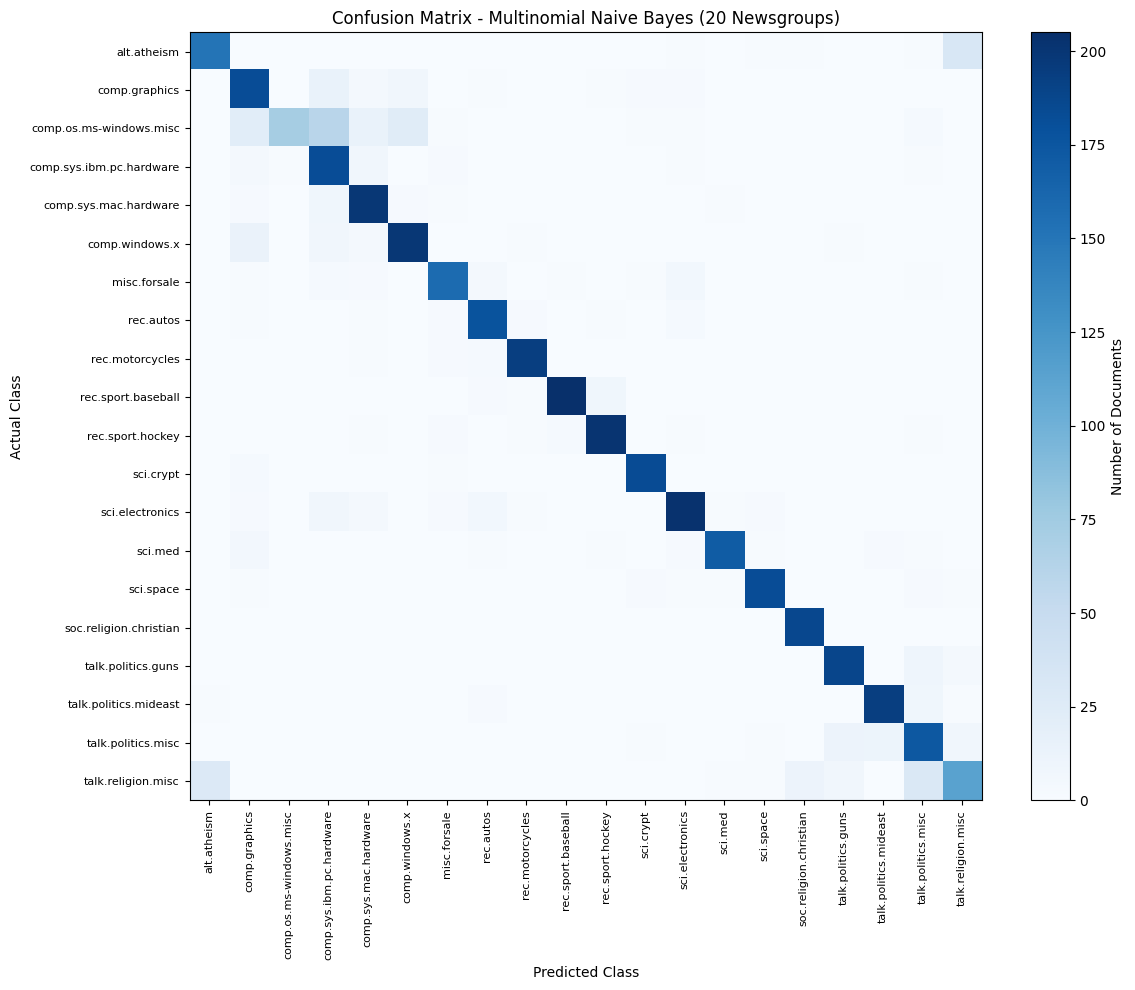

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(cm, cmap='Blues', aspect='auto')

ax.set_title('Confusion Matrix - Multinomial Naive Bayes (20 Newsgroups)')
ax.set_xlabel('Predicted Class')
ax.set_ylabel('Actual Class')

ax.set_xticks(range(len(class_names)))
ax.set_yticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=90, fontsize=8)
ax.set_yticklabels(class_names, fontsize=8)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Number of Documents')

plt.tight_layout()
plt.show()